# Week 3: Layer Sweep - Finding the Optimal Probe Layer

## The Research Question

**Problem:**
- We guessed Layer 16 (middle) would encode abstract "code vs language" mode
- But this is arbitrary! Different layers encode different information:
  - **Early layers (0-5)**: Syntax, tokens, word embeddings
  - **Middle layers (10-20)**: Abstract concepts, intent, semantics
  - **Late layers (25-32)**: Word prediction, vocabulary selection

**Solution: Layer Ablation Study**
- Train probe on **ALL 32 layers** (0-31)
- Measure accuracy and separation for each
- Pick the **empirically best** layer

**Why this is real research:**
- ✅ Evidence-based (not guessing)
- ✅ Ablation study (standard in NLP papers)
- ✅ Shows where "mode" information emerges
- ✅ Falsifiable hypothesis

**References:**
- Belinkov et al. (2017): "What do Neural Machine Translation Models Learn about Morphology?"
- Tenney et al. (2019): "BERT Rediscovers the Classical NLP Pipeline"

---

In [1]:
# Cell 1: Install
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn

In [2]:
# Cell 2: Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, train_test_split
from scipy.stats import ttest_ind
from tqdm.notebook import tqdm
import pickle

np.random.seed(42)
torch.manual_seed(42)
print("✅ Imports")

✅ Imports


In [3]:
# Cell 3: Load Model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()

print(f"✅ Model loaded")
print(f"Total layers: {model.config.num_hidden_layers}")

Loading codellama/CodeLlama-7b-Instruct-hf...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Model loaded
Total layers: 32


## Training Data

In [4]:
# Cell 4: Training prompts (expanded for better coverage)

CODE_PROMPTS = [
    # Python
    "def calculate_sum(a, b):",
    "import pandas as pd",
    "for i in range(10):",
    "class UserManager:",
    "if __name__ == '__main__':",
    "return {",
    "df = pd.read_csv(",
    "plt.plot(x, y)",
    "print(f'Value:",
    "try:\n    data =",
    "x = [i for i in",
    "with open('file.txt')",
    "lambda x: x",
    "async def fetch():",
    "@app.route('/api')",

    # JavaScript
    "const data = await",
    "function handleClick() {",
    "export default",
    "Promise.all(",
    "const [state, setState] =",
    "useEffect(() => {",
    "arr.map(item =>",

    # SQL
    "SELECT * FROM users",
    "INSERT INTO orders",
    "UPDATE table SET",
    "CREATE TABLE users (",
    "JOIN orders ON",

    # CLI/DevOps
    "git commit -m",
    "docker build -t",
    "npm run build",
    "pip install",
    "kubectl apply -f",

    # ML/Data Science
    "model.fit(X, y)",
    "df.groupby(",
    "np.array([",
    "torch.nn.Linear(",
]

LANGUAGE_PROMPTS = [
    "The quick brown fox",
    "Explain the theory of",
    "Once upon a time",
    "The weather today is",
    "I need help with",
    "To bake a cake, you",
    "The capital of France",
    "History teaches us that",
    "In conclusion,",
    "Please describe the",
    "The main difference is",
    "However, we can see",
    "It is important to",
    "According to the study,",
    "For example,",
    "This suggests that",
    "On the other hand,",
    "Writing a good essay",
    "The meaning of life",
    "How do I cook",
    "What is the best way",
    "Can you tell me",
    "I am feeling happy",
    "The movie was great",
    "She walked into the",
    "The purpose of this",
    "Let me explain why",
    "First of all,",
    "Another important point",
    "In other words,",
    "To summarize,",
    "The reason for this",
    "Most people believe",
    "It seems that",
    "We should consider",
    "Many experts agree",
]

y = np.array([1] * len(CODE_PROMPTS) + [0] * len(LANGUAGE_PROMPTS))

print(f"Training data:")
print(f"  Code prompts: {len(CODE_PROMPTS)}")
print(f"  Language prompts: {len(LANGUAGE_PROMPTS)}")
print(f"  Total samples: {len(y)}")

Training data:
  Code prompts: 36
  Language prompts: 36
  Total samples: 72


## Extract Hidden States from All Layers

In [5]:
# Cell 5: Extract all layers

def extract_all_layers(prompts: List[str]) -> np.ndarray:
    """
    Extract hidden states from ALL layers for a list of prompts.

    Returns:
        np.ndarray of shape (num_prompts, num_layers, hidden_dim)
    """
    all_layer_states = []

    for prompt in tqdm(prompts, desc="Extracting"):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        # outputs.hidden_states is tuple of 33 tensors:
        # [0] = embeddings
        # [1-32] = layers 0-31
        # Get last token [:, -1, :]
        layer_vectors = np.stack([
            layer[0, -1, :].cpu().numpy()
            for layer in outputs.hidden_states
        ])
        all_layer_states.append(layer_vectors)

    return np.stack(all_layer_states)

print("Extracting hidden states from all layers...")
print("This will take ~2-3 minutes...")

X_code_all = extract_all_layers(CODE_PROMPTS)
X_lang_all = extract_all_layers(LANGUAGE_PROMPTS)

# Combine: shape (total_samples, num_layers, hidden_dim)
X_all = np.concatenate([X_code_all, X_lang_all], axis=0)
NUM_LAYERS = X_all.shape[1]

print(f"\n✅ Hidden states extracted")
print(f"Data shape: {X_all.shape}")
print(f"  Samples: {X_all.shape[0]}")
print(f"  Layers: {X_all.shape[1]}")
print(f"  Hidden dim: {X_all.shape[2]}")

Extracting hidden states from all layers...
This will take ~2-3 minutes...


Extracting:   0%|          | 0/36 [00:00<?, ?it/s]

Extracting:   0%|          | 0/36 [00:00<?, ?it/s]


✅ Hidden states extracted
Data shape: (72, 33, 4096)
  Samples: 72
  Layers: 33
  Hidden dim: 4096


## Layer Sweep with Multiple Metrics

In [6]:
# Cell 6: Helper for Cohen's d

def cohens_d(group1: np.ndarray, group2: np.ndarray) -> float:
    """
    Calculate Cohen's d effect size.
    Measures separation between two groups.

    |d| < 0.2: Small effect
    |d| < 0.5: Medium effect
    |d| >= 0.8: Large effect
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

print("✅ Cohen's d function defined")

✅ Cohen's d function defined


In [7]:
# Cell 7: Layer sweep

print("\n" + "="*80)
print("LAYER SWEEP: Training probes on all layers")
print("="*80)

results = []

for layer_idx in tqdm(range(NUM_LAYERS), desc="Sweeping layers"):
    # Get data for this layer only
    X_layer = X_all[:, layer_idx, :]

    # Split for validation
    X_train, X_test, y_train, y_test = train_test_split(
        X_layer, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train probe
    probe = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    probe.fit(X_train, y_train)

    # Evaluate
    y_pred = probe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-validation on full dataset (more robust)
    cv_scores = cross_val_score(probe, X_layer, y, cv=5)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    # Cohen's d (separation between code and language in this layer)
    # Get decision function scores
    code_scores = probe.decision_function(X_code_all[:, layer_idx, :])
    lang_scores = probe.decision_function(X_lang_all[:, layer_idx, :])
    d = cohens_d(code_scores, lang_scores)

    results.append({
        'layer': layer_idx,
        'accuracy': acc,
        'f1_score': f1,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'cohens_d': d,
        'probe': probe,  # Save for best layer
    })

df_results = pd.DataFrame(results)

print("\n✅ Layer sweep complete")
print(f"\nTop 5 layers by CV accuracy:")
print(df_results.nlargest(5, 'cv_mean')[['layer', 'cv_mean', 'cv_std', 'cohens_d']])


LAYER SWEEP: Training probes on all layers


Sweeping layers:   0%|          | 0/33 [00:00<?, ?it/s]


✅ Layer sweep complete

Top 5 layers by CV accuracy:
    layer   cv_mean    cv_std  cohens_d
31     31  1.000000  0.000000  8.073617
32     32  1.000000  0.000000  8.320457
7       7  0.986667  0.026667  7.211471
8       8  0.986667  0.026667  7.102782
13     13  0.986667  0.026667  7.745868


## Find Best Layer

In [8]:
# Cell 8: Identify best layer

# Best by cross-validation accuracy
best_idx = df_results['cv_mean'].idxmax()
best_layer = df_results.loc[best_idx, 'layer']
best_acc = df_results.loc[best_idx, 'cv_mean']
best_std = df_results.loc[best_idx, 'cv_std']
best_d = df_results.loc[best_idx, 'cohens_d']
best_probe = df_results.loc[best_idx, 'probe']

print("\n" + "="*80)
print("🏆 BEST LAYER FOUND")
print("="*80)
print(f"\nLayer: {best_layer}")
print(f"CV Accuracy: {best_acc:.1%} (+/- {best_std:.1%})")
print(f"Cohen's d: {best_d:.2f} ({'Large' if abs(best_d) >= 0.8 else 'Medium' if abs(best_d) >= 0.5 else 'Small'} effect)")
print(f"\n📝 Recommendation: Use PROBE_LAYER = {best_layer} in your main script")

# Save best probe
with open(f'best_probe_layer{best_layer}.pkl', 'wb') as f:
    pickle.dump(best_probe, f)
print(f"\n✅ Best probe saved to: best_probe_layer{best_layer}.pkl")


🏆 BEST LAYER FOUND

Layer: 31
CV Accuracy: 100.0% (+/- 0.0%)
Cohen's d: 8.07 (Large effect)

📝 Recommendation: Use PROBE_LAYER = 31 in your main script

✅ Best probe saved to: best_probe_layer31.pkl


## Visualizations

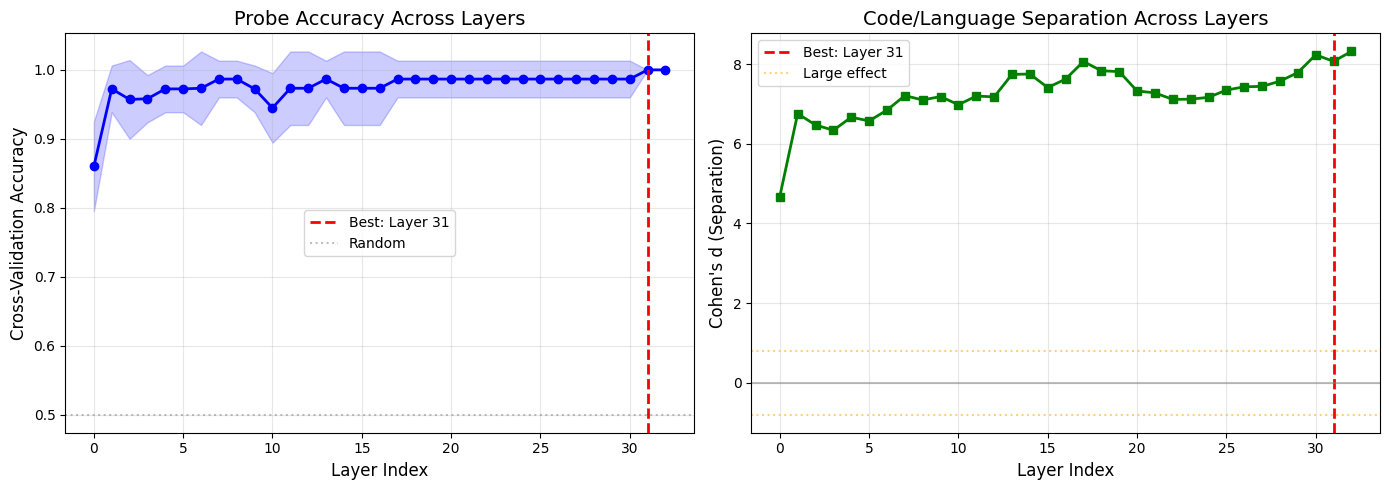

✅ Accuracy plot saved


In [9]:
# Cell 9: Plot accuracy across layers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CV Accuracy by layer
ax = axes[0]
ax.plot(df_results['layer'], df_results['cv_mean'], marker='o', color='blue', linewidth=2)
ax.fill_between(df_results['layer'],
                df_results['cv_mean'] - df_results['cv_std'],
                df_results['cv_mean'] + df_results['cv_std'],
                alpha=0.2, color='blue')
ax.axvline(best_layer, color='red', linestyle='--', linewidth=2, label=f'Best: Layer {best_layer}')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random')
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title('Probe Accuracy Across Layers', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Cohen's d by layer
ax = axes[1]
ax.plot(df_results['layer'], df_results['cohens_d'], marker='s', color='green', linewidth=2)
ax.axvline(best_layer, color='red', linestyle='--', linewidth=2, label=f'Best: Layer {best_layer}')
ax.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax.axhline(0.8, color='orange', linestyle=':', alpha=0.5, label='Large effect')
ax.axhline(-0.8, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel("Cohen's d (Separation)", fontsize=12)
ax.set_title('Code/Language Separation Across Layers', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week3_layer_sweep_results.png', dpi=150)
plt.show()

print("✅ Accuracy plot saved")


Generating PCA visualization for Layer 31...


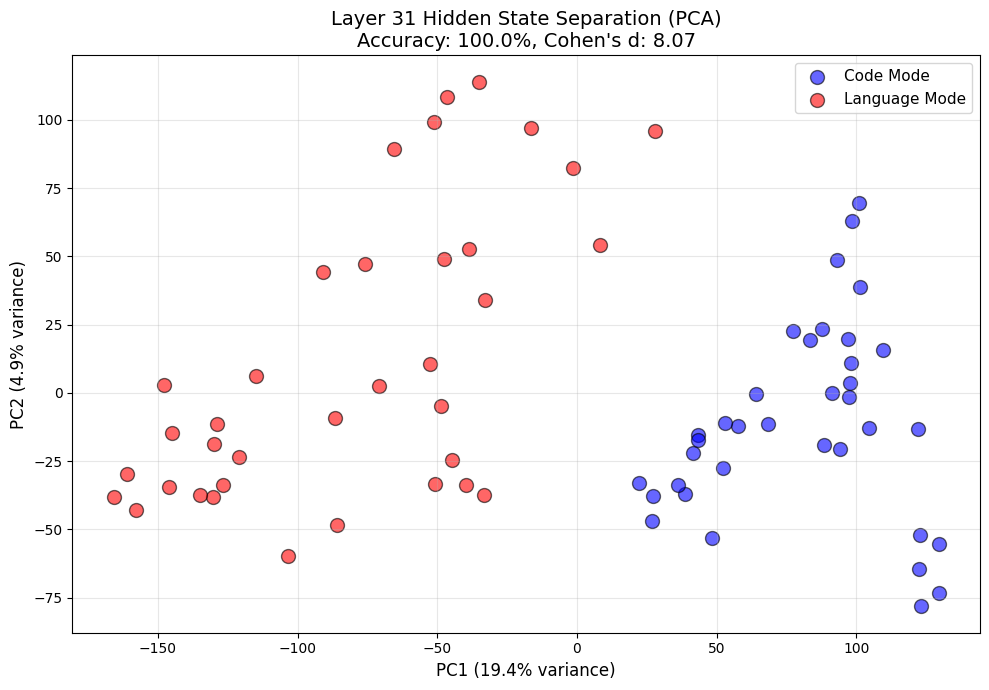

✅ PCA plot saved for Layer 31

Variance explained: 24.4%


In [10]:
# Cell 10: PCA visualization for best layer

print(f"\nGenerating PCA visualization for Layer {best_layer}...")

# Get data for best layer
X_best = X_all[:, best_layer, :]

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_best)

# Split into code and language
X_code_pca = X_pca[:len(CODE_PROMPTS)]
X_lang_pca = X_pca[len(CODE_PROMPTS):]

plt.figure(figsize=(10, 7))
plt.scatter(X_code_pca[:, 0], X_code_pca[:, 1],
            c='blue', label='Code Mode', s=100, alpha=0.6, edgecolors='black')
plt.scatter(X_lang_pca[:, 0], X_lang_pca[:, 1],
            c='red', label='Language Mode', s=100, alpha=0.6, edgecolors='black')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'Layer {best_layer} Hidden State Separation (PCA)\nAccuracy: {best_acc:.1%}, Cohen\'s d: {best_d:.2f}', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'week3_layer{best_layer}_pca.png', dpi=150)
plt.show()

print(f"✅ PCA plot saved for Layer {best_layer}")
print(f"\nVariance explained: {pca.explained_variance_ratio_[:2].sum():.1%}")

In [11]:
# Cell 11: Summary statistics

print("\n" + "="*80)
print("LAYER SWEEP SUMMARY")
print("="*80)

print(f"\nTotal layers tested: {NUM_LAYERS}")
print(f"\nAccuracy ranges:")
print(f"  Min: {df_results['cv_mean'].min():.1%} (Layer {df_results['cv_mean'].idxmin()})")
print(f"  Max: {df_results['cv_mean'].max():.1%} (Layer {df_results['cv_mean'].idxmax()})")
print(f"  Range: {df_results['cv_mean'].max() - df_results['cv_mean'].min():.1%}")

print(f"\nLayers with accuracy > 80%:")
good_layers = df_results[df_results['cv_mean'] > 0.80]
if len(good_layers) > 0:
    for _, row in good_layers.iterrows():
        print(f"  Layer {row['layer']}: {row['cv_mean']:.1%} (d={row['cohens_d']:.2f})")
else:
    print("  None")

print(f"\nRecommendation:")
print(f"  Use PROBE_LAYER = {best_layer} in Week3_Deep_Probe_CCE_Fixed.ipynb")
print(f"  Load probe from: best_probe_layer{best_layer}.pkl")

# Save full results
df_results_save = df_results.drop('probe', axis=1)  # Can't pickle in CSV
df_results_save.to_csv('week3_layer_sweep_results.csv', index=False)
print(f"\n✅ Full results saved to: week3_layer_sweep_results.csv")

print("\n" + "="*80)


LAYER SWEEP SUMMARY

Total layers tested: 33

Accuracy ranges:
  Min: 86.0% (Layer 0)
  Max: 100.0% (Layer 31)
  Range: 14.0%

Layers with accuracy > 80%:
  Layer 0: 86.0% (d=4.68)
  Layer 1: 97.2% (d=6.76)
  Layer 2: 95.7% (d=6.47)
  Layer 3: 95.8% (d=6.34)
  Layer 4: 97.2% (d=6.67)
  Layer 5: 97.2% (d=6.58)
  Layer 6: 97.3% (d=6.85)
  Layer 7: 98.7% (d=7.21)
  Layer 8: 98.7% (d=7.10)
  Layer 9: 97.2% (d=7.19)
  Layer 10: 94.5% (d=6.98)
  Layer 11: 97.3% (d=7.20)
  Layer 12: 97.3% (d=7.18)
  Layer 13: 98.7% (d=7.75)
  Layer 14: 97.3% (d=7.75)
  Layer 15: 97.3% (d=7.41)
  Layer 16: 97.3% (d=7.63)
  Layer 17: 98.7% (d=8.07)
  Layer 18: 98.7% (d=7.84)
  Layer 19: 98.7% (d=7.81)
  Layer 20: 98.7% (d=7.33)
  Layer 21: 98.7% (d=7.28)
  Layer 22: 98.7% (d=7.12)
  Layer 23: 98.7% (d=7.12)
  Layer 24: 98.7% (d=7.17)
  Layer 25: 98.7% (d=7.35)
  Layer 26: 98.7% (d=7.43)
  Layer 27: 98.7% (d=7.44)
  Layer 28: 98.7% (d=7.58)
  Layer 29: 98.7% (d=7.79)
  Layer 30: 98.7% (d=8.24)
  Layer 31: 100.0

## Interpretation Guide

### Expected Patterns:

**Early Layers (0-5):**
- Accuracy ~50-65%
- Low Cohen's d
- These layers process syntax and tokens, not abstract intent

**Middle Layers (8-20):**
- Accuracy should RISE sharply
- High Cohen's d (>0.8)
- This is where "I'm writing code" vs "I'm writing English" emerges
- **Expect best layer here**

**Late Layers (25-32):**
- Accuracy might DROP slightly
- Lower Cohen's d
- These layers prepare for specific word prediction
- Abstract mode information may collapse

### What to Look For:

1. **Sharp rise in accuracy** → Mode information emerges
2. **Plateau** → Information is stable
3. **Drop near end** → Information collapses to word prediction

### Research Implications:

- If best layer is **early** (0-7): Model encodes mode very early
- If best layer is **middle** (8-20): Standard transformer behavior
- If best layer is **late** (21-31): Unusual, may indicate model peculiarity

---